In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium
import contextily as ctx
from shapely.geometry import shape
import pyproj
import mapclassify
import numpy as np

In [4]:
regions_df = pd.read_csv('data/Regions_Places.csv')
regions_df = regions_df.dropna(subset=['Region/Places'])
regions_df = regions_df.drop_duplicates(subset=['Region/Places'])

# Create admin1 codes from Region/Places
regions_df['Admin1_Code'] = pd.factorize(regions_df['Region/Places'])[0]
region_mapping = dict(zip(regions_df['Region/Places'], regions_df['Admin1_Code']))
print("Region mapping created with", len(region_mapping), "entries")

Region mapping created with 343 entries


In [5]:
icpac_countries = ["BDI", "DJI", "ETH", "KEN", "RWA", "SOM", "SSD", "SDN", "TZA", "UGA", "ERI"]
gdfs = []

for country_code in icpac_countries:
    try:
        url = f"https://github.com/wmgeolab/geoBoundaries/raw/main/releaseData/gbOpen/{country_code}/ADM1/geoBoundaries-{country_code}-ADM1_simplified.geojson"
        gdf = gpd.read_file(url)
        gdf['admin1_code'] = gdf['shapeName'].map(region_mapping)
        gdf = gdf.dropna(subset=['admin1_code'])
        
        gdf['gaul_admin1_code'] = gdf['shapeISO'].astype(str) + '_' + gdf['shapeID'].astype(str)
        gdf['geob_admin1_shapeID'] = gdf['shapeID']
        
        print(f"Processed {len(gdf)} admin1 boundaries for {country_code}")
        gdfs.append(gdf)
    except Exception as e:
        print(f"Error loading {country_code} GeoJSON file:", str(e))
        gdf = gpd.GeoDataFrame()

# Combine all country dataframes
combined_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
print("Total processed admin1 boundaries:", len(combined_gdf))

Processed 1 admin1 boundaries for BDI
Processed 0 admin1 boundaries for DJI
Processed 4 admin1 boundaries for ETH
Processed 10 admin1 boundaries for KEN
Processed 0 admin1 boundaries for RWA
Processed 3 admin1 boundaries for SOM
Processed 8 admin1 boundaries for SSD
Processed 15 admin1 boundaries for SDN
Processed 1 admin1 boundaries for TZA
Processed 0 admin1 boundaries for UGA
Processed 0 admin1 boundaries for ERI
Total processed admin1 boundaries: 42


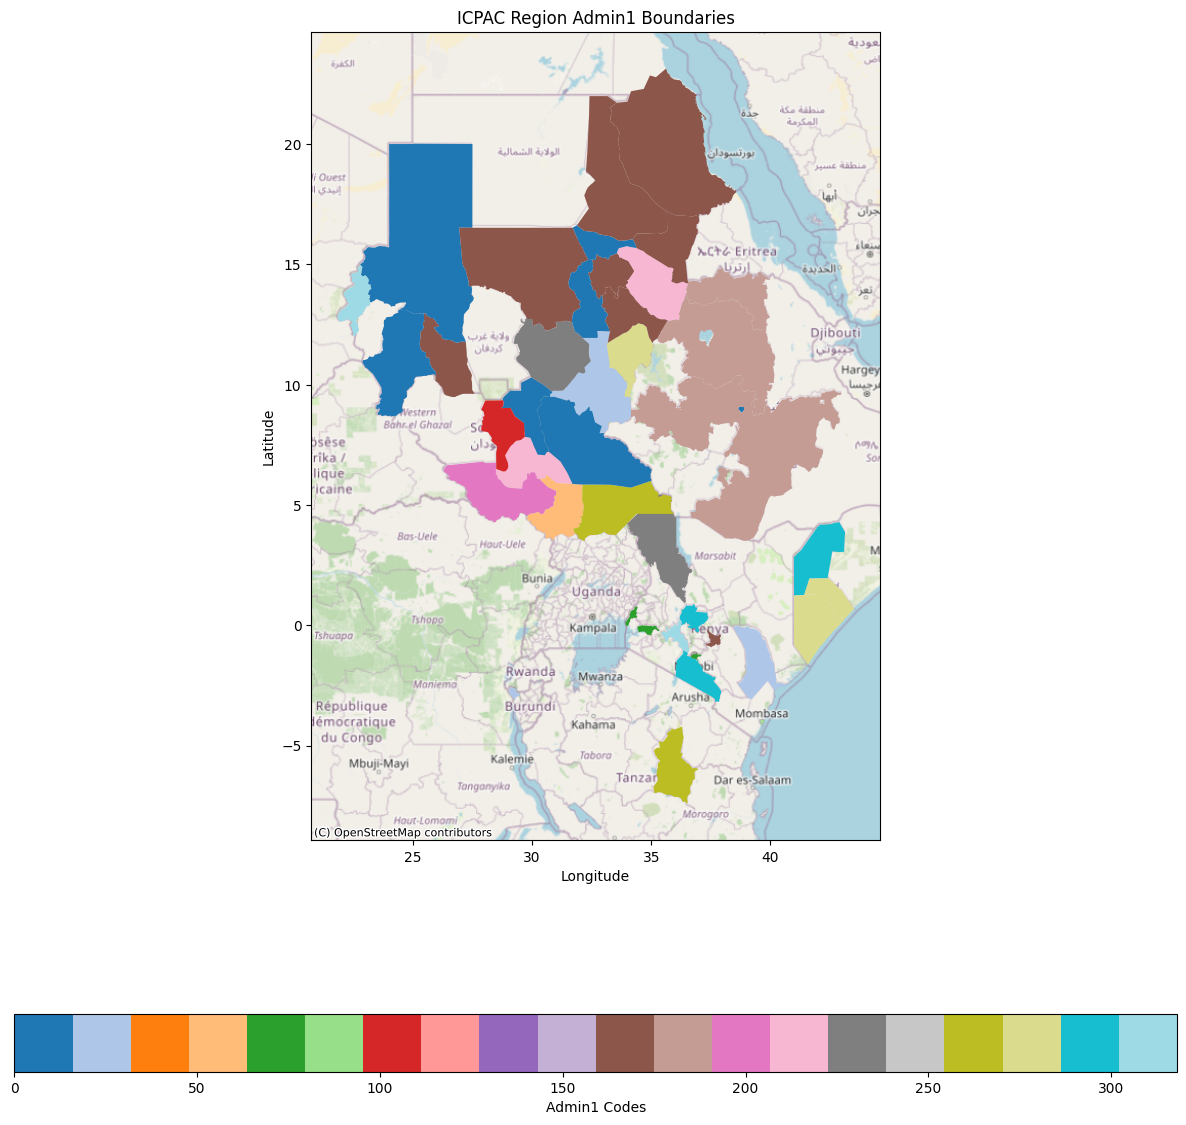

In [6]:
if not combined_gdf.empty:
    fig, ax = plt.subplots(figsize=(15, 15))
    combined_gdf.plot(ax=ax, column='admin1_code', cmap='tab20', legend=True,
             legend_kwds={'label': "Admin1 Codes", 'orientation': "horizontal"})
    ctx.add_basemap(ax, crs=combined_gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
    plt.title("ICPAC Region Admin1 Boundaries")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

In [7]:
if not combined_gdf.empty:
    m = folium.Map(location=[8, 38], zoom_start=6)
    folium.GeoJson(
        combined_gdf,
        style_function=lambda feature: {
            'fillColor': plt.cm.tab20(feature['properties']['admin1_code']),
            'color': 'black',
            'weight': 1,
            'fillOpacity': 0.7
        }
    ).add_to(m)
    display(m)

In [8]:
# Save admin1 codes to a CSV file
if not combined_gdf.empty:
    admin1_codes = combined_gdf[['shapeName', 'admin1_code', 'gaul_admin1_code', 'geob_admin1_shapeID']].drop_duplicates()
    admin1_codes.to_csv('admin1_codes.csv', index=False)
    print("Admin1 codes saved to admin1_codes.csv")

Admin1 codes saved to admin1_codes.csv
